In [125]:
import pandas as pd
import numpy as np

In [126]:
df = pd.read_csv('features.csv')

# Filter where the first column equals "Linear"
linear = df[df.iloc[:, 0] == "Linear"].copy()


In [127]:
# Select input features (X) and output conditions (y)
X = linear.iloc[:, 4:7]
y = linear.iloc[:, 1]

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=21)

In [129]:
# Normalise all variables
from sklearn.preprocessing import StandardScaler

scale_standard = StandardScaler()

X_train = scale_standard.fit_transform(X_train)

# Revert back to pandas data frame
X_train = pd.DataFrame(X_train, columns=['mean', 'rms', 'std'])



In [130]:
from sklearn.decomposition import PCA

# Compute a 3 component PCA
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_train)

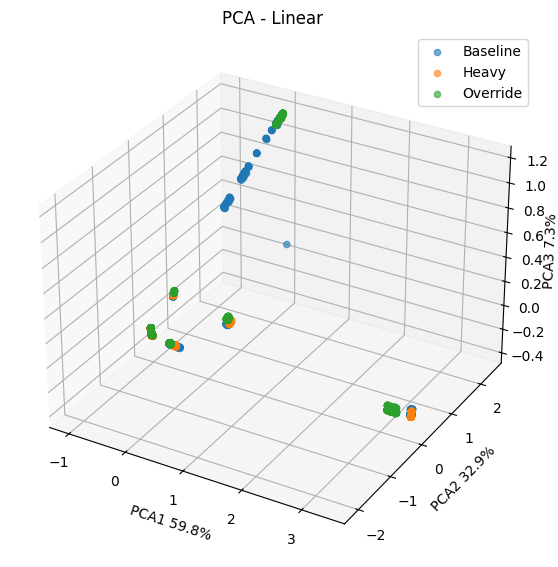

In [131]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14,7))
ax = fig.add_subplot(111, projection='3d')

for condition in np.unique(y_train):
    mask = (y_train == condition)
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        X_pca[mask, 2],      
        label=condition, 
        alpha=0.6
    )

# Label all axes with percentage of explained variance
ax.set_xlabel(f'PCA1 {pca.explained_variance_ratio_[0].round(3)*100}%')
ax.set_ylabel(f'PCA2 {pca.explained_variance_ratio_[1].round(3)*100}%')
ax.set_zlabel(f'PCA3 {pca.explained_variance_ratio_[2].round(3)*100}%', labelpad=-1)
ax.set_title("PCA - Linear")

fig.subplots_adjust(right=0.5)
ax.legend(loc='upper right')
plt.show()

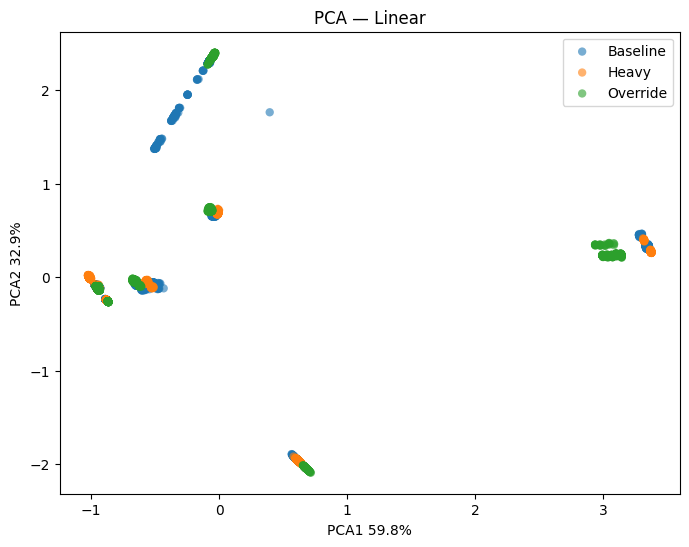

In [132]:
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_train)

# 2. Initialize a standard 2D plot (no projection='3d' needed)
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through each unique category and plot them separately
for condition in np.unique(y_train):
    # Create a mask to isolate only the current condition's rows
    mask = (y_train == condition)
    
    # Plot just this group
    ax.scatter(
        X_pca[mask, 0], 
        X_pca[mask, 1], 
        label=condition,      # <-- CRITICAL: This assigns the text to the legend
        alpha=0.6,            # Adds transparency like your image
        edgecolors='none'     # Removes borders for a cleaner look
    )

# Standard axis labeling
ax.set_xlabel(f'PCA1 {pca.explained_variance_ratio_[0].round(3)*100}%')
ax.set_ylabel(f'PCA2 {pca.explained_variance_ratio_[1].round(3)*100}%')
ax.set_title('PCA — Linear')

# THE MAGIC LINE: Call legend() instead of colorbar()
ax.legend(loc='upper right', scatterpoints=1, frameon=True)

plt.show()